In [10]:
import qiskit 

from qiskit import QuantumCircuit

In [11]:
n=25
t1= QuantumCircuit(n)

t1.h(0)

for i in range(n-1):
    t1.cx(i,i+1)




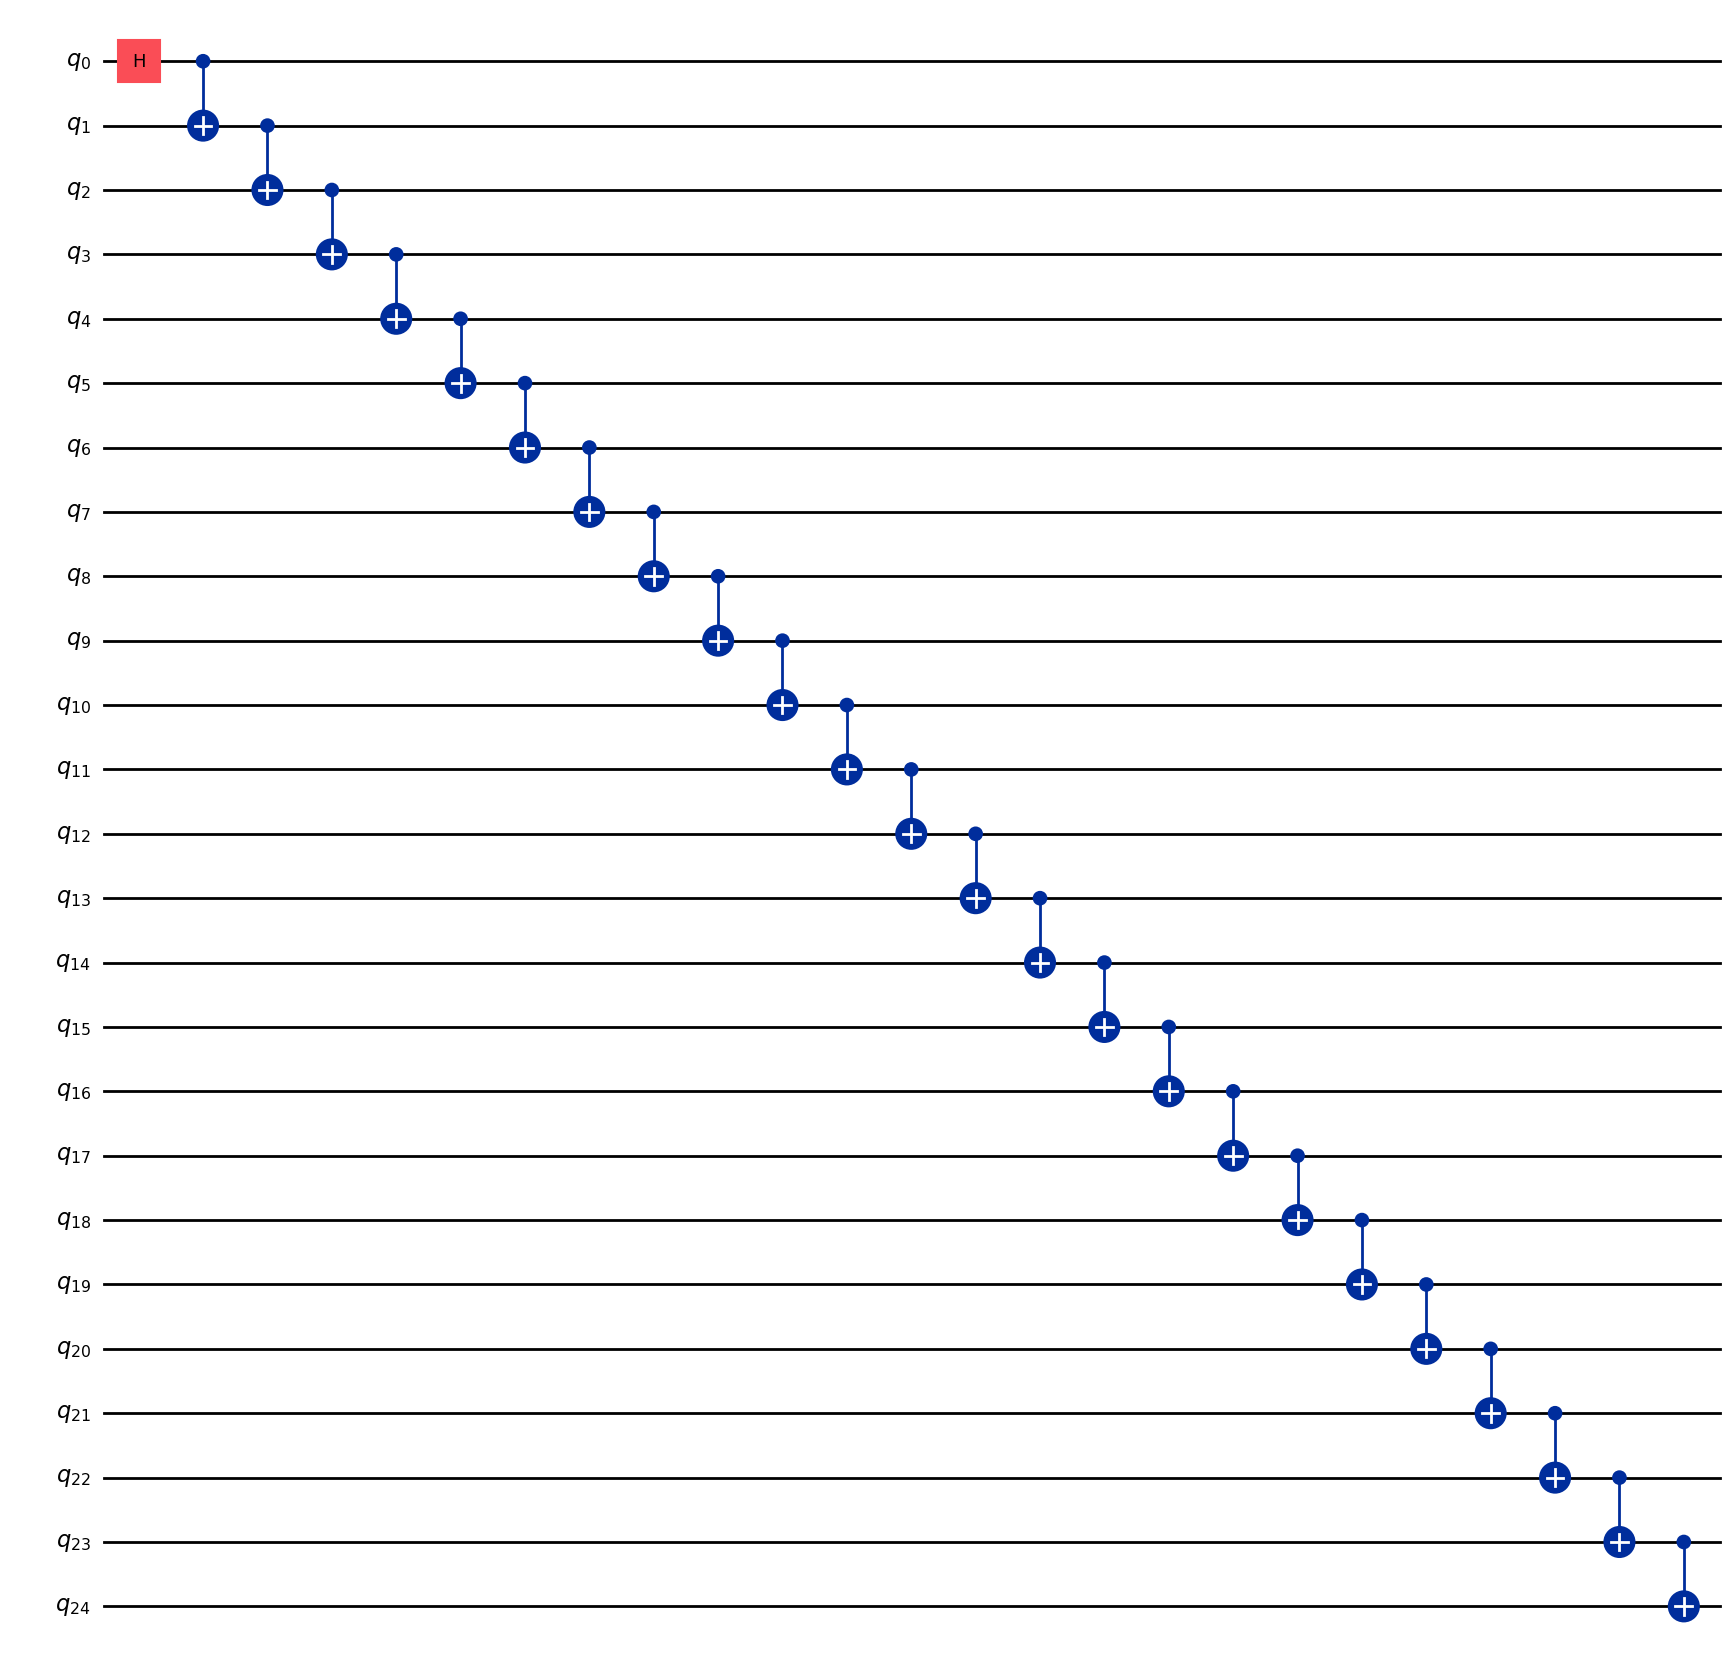

In [12]:
t1.draw(output='mpl')

In [13]:
from qiskit.quantum_info import SparsePauliOp

strings=['Z'+'I'*x +"Z"+'I'*(n-2-x)  for x in range(n-1)]

operators=[SparsePauliOp(string )for string in strings]

In [14]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend_name='ibm_kingston'

service=QiskitRuntimeService()

backend=service.backend(backend_name)

pass_manager=generate_preset_pass_manager(optimization_level =1,backend=backend)
t1_transpiled=pass_manager.run(t1)

operators_transpiled=[op.apply_layout(t1_transpiled.layout) for op in operators]


qiskit_runtime_service.__init__:WARNING:2026-05-27 15:25:15,197: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-27 15:25:15,198: Using instance: open-instance, plan: open


from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions

options=EstimatorOptions()

options.resilience_level=1
options.dynamical_decoupling.enable=True
options.dynamical_decoupling.sequence_type='XY4'

estimator=Estimator(backend,options=options)

job=estimator.run([(t1_transpiled,operators_transpiled)])

job_id=job.job_id()

print(job_id)

In [20]:
from qiskit_aer import AerSimulator

available_devices = AerSimulator().available_devices()
print(f"Aer devices available in this environment: {available_devices}")


Aer devices available in this environment: ('CPU',)


In [ ]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator

available_devices = AerSimulator().available_devices()
device = "GPU" if "GPU" in available_devices else "CPU"
print(f"Using Aer device: {device} (available: {available_devices})")

estimator = Estimator(options={"backend_options": {"device": device}})

# Run the job
job = estimator.run([(t1_transpiled, operators_transpiled)])
result = job.result()

# Extract expectation values
expectation_values = result[0].data.evs
print(expectation_values)
